# 주얼리 이커머스 Meta 광고 성과 구조 분석
**어떤 운영 방식과 광고 소재가 Meta 광고 성과를 만드는가?**

---

## 프로젝트 개요

| 항목 | 내용 |
|------|------|
| 분석 대상 | 원석팔찌·커플세트 주얼리 이커머스 A사 |
| 분석 기간 | 2025.01.01 ~ 2025.12.31 (1년 전체) |
| 데이터 | Meta 광고 관리자 + 자사몰 주문 연계 데이터 |
| 운영 규모 | 캠페인 102 / 광고세트 128 / 광고 1,331 |

### 분석 목적
1. Meta 광고 알고리즘 최적화와 관련된 **비효율 구간 발견**
2. 실제 성과를 만드는 **메시지·소재 전략 도출**
3. 재현 가능한 **광고 운영 기준 수립**

> ※ 기업 데이터 보호를 위해 구체 금액·캠페인명은 마스킹 처리되었습니다.
> ※ 데이터는 월별 CSV를 SQL로 통합한 후 분석에 활용하였습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 로드
ads_2025 = pd.read_csv('2025_meta_ads_daily_final.csv', encoding='utf-8-sig')
products = pd.read_csv('상품정보_20251030.csv', encoding='utf-8-sig')

# URL에서 product_no 추출 후 상품 정보 병합
ads_2025['product_no'] = pd.to_numeric(
    ads_2025['웹사이트 URL'].str.extract(r'/(\d+)/')[0], errors='coerce'
)
products['product_no'] = pd.to_numeric(products['product_no'], errors='coerce')
products = products.dropna(subset=['product_no'])

ads_df = pd.merge(
    ads_2025,
    products[['product_no', 'product_name']],
    on='product_no',
    how='left'
)

print(f"광고 데이터: {ads_df.shape[0]:,}행 × {ads_df.shape[1]}열")

광고 데이터: 21,197행 × 40열


---
## PART 1 — 광고 성과 구조 분석 (Performance)

> "성과를 만드는 운영 구조인가?"

Meta 광고는 7일 이후 약 50회 이상 전환이 발생하면 알고리즘 학습이 안정화된 상태(최적화)로 볼 수 있다.

In [3]:
import pandas as pd
import numpy as np

df = ads_df.copy()

df["일"] = pd.to_datetime(df["일"], errors="coerce")
df["광고 시작일"] = pd.to_datetime(df["광고 시작일"], errors="coerce")
df["성과 목표"] = df["성과 목표"].astype("string").str.strip()
df["결과 유형"] = df["결과 유형"].astype("string").str.strip()

num_cols = [
    "광고 기간", "노출", "도달", "조회", "결과", "지출 금액 (KRW)",
    "링크 클릭", "구매 전환값", "구매", "랜딩 페이지 조회"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_window = df[df["광고 기간"] >= 7].copy()

adset_meta = (
    df.groupby("광고 세트 ID", as_index=False)
    .agg(
        캠페인_이름=("캠페인 이름", "first"),
        광고세트_이름=("광고 세트 이름", "first"),
        성과_목표=("성과 목표", "first"),
        결과_유형=("결과 유형", "first"),
        product_no=("product_no", "first"),
        product_name=("product_name", "first")
    )
)

conv = (
    df_window.groupby("광고 세트 ID", as_index=False)
    .agg(purchases_7d=("구매", "sum"), landing_page_views_7d=("랜딩 페이지 조회", "sum"))
    .merge(adset_meta, on="광고 세트 ID", how="left")
)

conv["conv_7d"] = np.where(conv["성과_목표"] == "전환", conv["purchases_7d"], conv["landing_page_views_7d"])
conv["optimization_status"] = np.where(conv["conv_7d"] >= 50, "optimized", "not_optimized")

all_ids = pd.DataFrame({"광고 세트 ID": df["광고 세트 ID"].dropna().unique()})
optimization_map = all_ids.merge(conv[["광고 세트 ID", "conv_7d", "optimization_status"]], on="광고 세트 ID", how="left")
optimization_map["optimization_status"] = optimization_map["optimization_status"].fillna("not_optimized")

ad_summary_all = (
    df.groupby("광고 세트 ID", dropna=False)
    .agg(impressions=("노출","sum"), reach=("도달","sum"), views=("조회","sum"),
         link_clicks=("링크 클릭","sum"), landing_page_views=("랜딩 페이지 조회","sum"),
         purchases=("구매","sum"), purchase_value=("구매 전환값","sum"),
         spend_krw=("지출 금액 (KRW)","sum"), results=("결과","sum"),
         ad_days=("광고 기간","max"))
    .reset_index()
)

ad_summary_all = (
    ad_summary_all
    .merge(adset_meta, on="광고 세트 ID", how="left")
    .merge(optimization_map, on="광고 세트 ID", how="left")
)

ad_summary_all["ctr_link_calc"] = np.where(ad_summary_all["impressions"]>0, ad_summary_all["link_clicks"]/ad_summary_all["impressions"], np.nan)
ad_summary_all["roas_calc"] = np.where(ad_summary_all["spend_krw"]>0, ad_summary_all["purchase_value"]/ad_summary_all["spend_krw"], np.nan)

ad_summary_all["ad_goal"] = None
ad_summary_all.loc[ad_summary_all["성과_목표"]=="전환", "ad_goal"] = "conversion"
ad_summary_all.loc[ad_summary_all["성과_목표"].isin(["링크 클릭","랜딩 페이지 조회"]), "ad_goal"] = "traffic"
ad_summary_all = ad_summary_all.dropna(subset=["ad_goal"])
ad_summary_all["group"] = ad_summary_all["optimization_status"] + "_" + ad_summary_all["ad_goal"]

# 캠페인명 마스킹
ad_summary_all["광고세트_이름"] = "adset_" + ad_summary_all.reset_index().index.astype(str)

print(ad_summary_all["group"].value_counts(dropna=False))

group
not_optimized_conversion    71
optimized_conversion        25
optimized_traffic           21
not_optimized_traffic        7
Name: count, dtype: int64


In [4]:
optimized_conversion = ad_summary_all[ad_summary_all["group"] == "optimized_conversion"]
optimized_traffic = ad_summary_all[ad_summary_all["group"] == "optimized_traffic"]
not_optimized_conversion = ad_summary_all[ad_summary_all["group"] == "not_optimized_conversion"]
not_optimized_traffic = ad_summary_all[ad_summary_all["group"] == "not_optimized_traffic"]

conv_ads = ad_summary_all[ad_summary_all["ad_goal"] == "conversion"].copy()

# 미최적화 7일 미만 광고
not_opt_conv = not_optimized_conversion[not_optimized_conversion["ad_days"] < 7].copy()
not_opt_traffic = not_optimized_traffic[not_optimized_traffic["ad_days"] < 7].copy()

color_map = {
    "optimized_conversion": "#1f4ed8",
    "not_optimized_conversion": "#93c5fd",
    "optimized_traffic": "#f97316",
    "not_optimized_traffic": "#fdba74"
}

print(f"최적화 구매: {len(optimized_conversion)}개 / 미최적화 구매: {len(not_optimized_conversion)}개")
print(f"최적화 트래픽: {len(optimized_traffic)}개 / 미최적화 트래픽: {len(not_optimized_traffic)}개")
print(f"\n조기 종료(7일 미만) — 구매: {len(not_opt_conv)}개 / 트래픽: {len(not_opt_traffic)}개")

최적화 구매: 25개 / 미최적화 구매: 71개
최적화 트래픽: 21개 / 미최적화 트래픽: 7개

조기 종료(7일 미만) — 구매: 15개 / 트래픽: 7개


### 1-1. ROAS 비교 (구매 광고: 최적화 vs 미최적화)

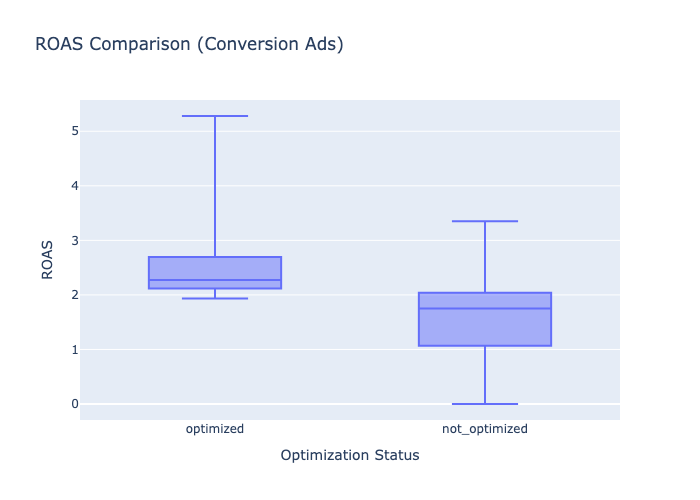

In [5]:
fig = px.box(
    conv_ads,
    x="optimization_status",
    y="roas_calc",
    points=False,
    title="ROAS Comparison (Conversion Ads)",
    height=500,
    labels={"optimization_status": "Optimization Status", "roas_calc": "ROAS"}
)
fig.show(renderer='png')

### 1-2. 광고비 vs ROAS / CTR (4개 그룹)

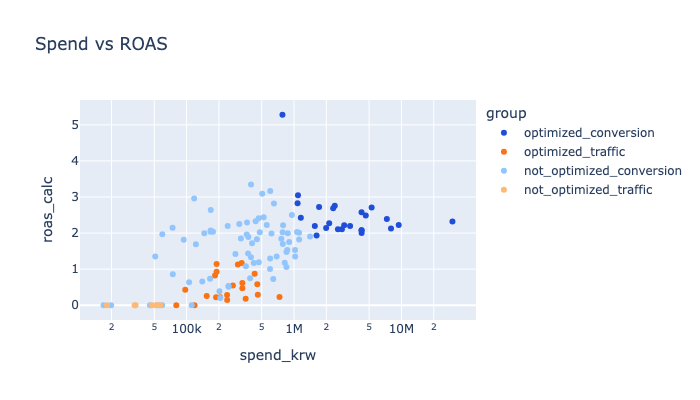

In [6]:
fig = px.scatter(
    ad_summary_all,
    x="spend_krw",
    y="roas_calc",
    color="group",
    color_discrete_map=color_map,
    height=400,
    log_x=True,
    title="Spend vs ROAS"
)
fig.show(renderer='png')

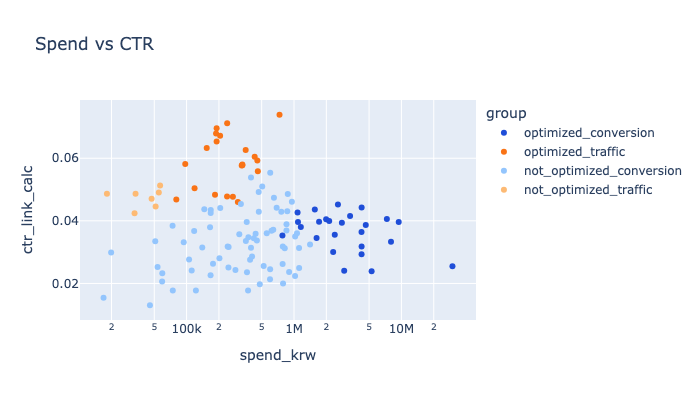

In [7]:
fig = px.scatter(
    ad_summary_all,
    x="spend_krw",
    y="ctr_link_calc",
    color="group",
    color_discrete_map=color_map,
    height=400,
    log_x=True,
    title="Spend vs CTR"
)
fig.show(renderer='png')

### 1-3. 광고 기간 vs ROAS

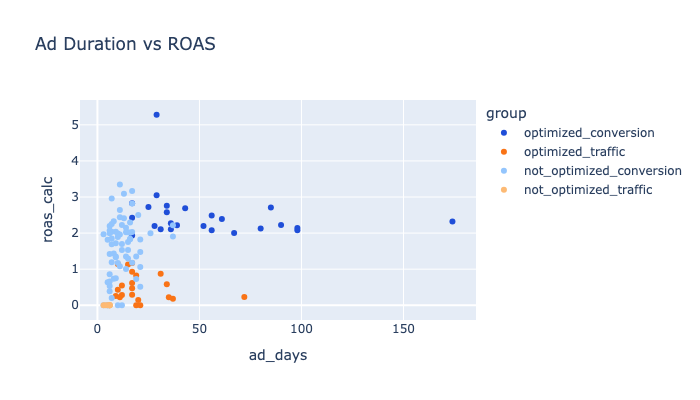

In [8]:
fig = px.scatter(
    ad_summary_all,
    x="ad_days",
    y="roas_calc",
    color="group",
    height=400,
    color_discrete_map=color_map,
    title="Ad Duration vs ROAS"
)
fig.show(renderer='png')

---
### 1-4. 잠재 광고 식별 — 조기 종료 광고 중 살릴 광고가 있는가?

7일 미만 조기 종료된 미최적화 광고를 **최적화 광고의 초기 일별 누적 성과 Q1**과 비교하여
잠재력이 있는 광고를 식별한다.

빨간 선(Q1 기준선) **위에 위치한 광고**는 잠재 광고로 판단할 수 있다.

In [9]:
# 최적화 광고 초기 7일 일별 누적 성과 Q1 계산

# 광고 시작 후 경과일
df["day_diff"] = (df["일"] - df["광고 시작일"]).dt.days
df_first7 = df[(df["day_diff"] >= 0) & (df["day_diff"] <= 6)].copy()

# 최적화 광고 ID
opt_conv_ids = ad_summary_all.loc[ad_summary_all["group"] == "optimized_conversion", "광고 세트 ID"].dropna().unique()
opt_traffic_ids = ad_summary_all.loc[ad_summary_all["group"] == "optimized_traffic", "광고 세트 ID"].dropna().unique()

# 광고세트+일자 단위 집계
conv_daily = (
    df_first7[df_first7["광고 세트 ID"].isin(opt_conv_ids)]
    .groupby(["광고 세트 ID", "day_diff"], as_index=False)
    .agg(results=("결과","sum"), purchase_value=("구매 전환값","sum"), spend_krw=("지출 금액 (KRW)","sum"))
    .sort_values(["광고 세트 ID", "day_diff"])
)

traffic_daily = (
    df_first7[df_first7["광고 세트 ID"].isin(opt_traffic_ids)]
    .groupby(["광고 세트 ID", "day_diff"], as_index=False)
    .agg(results=("결과","sum"), link_clicks=("링크 클릭","sum"), impressions=("노출","sum"))
    .sort_values(["광고 세트 ID", "day_diff"])
)

# 누적 성과 계산
conv_daily["cum_results"] = conv_daily.groupby("광고 세트 ID")["results"].cumsum()
conv_daily["cum_purchase_value"] = conv_daily.groupby("광고 세트 ID")["purchase_value"].cumsum()
conv_daily["cum_spend"] = conv_daily.groupby("광고 세트 ID")["spend_krw"].cumsum()
conv_daily["cum_roas"] = np.where(conv_daily["cum_spend"]>0, conv_daily["cum_purchase_value"]/conv_daily["cum_spend"], np.nan)

traffic_daily["cum_results"] = traffic_daily.groupby("광고 세트 ID")["results"].cumsum()
traffic_daily["cum_link_clicks"] = traffic_daily.groupby("광고 세트 ID")["link_clicks"].cumsum()
traffic_daily["cum_impressions"] = traffic_daily.groupby("광고 세트 ID")["impressions"].cumsum()
traffic_daily["cum_ctr"] = np.where(traffic_daily["cum_impressions"]>0, traffic_daily["cum_link_clicks"]/traffic_daily["cum_impressions"], np.nan)

# 각 n일차 기준 Q1 계산
conv_q1_by_day = (
    conv_daily[conv_daily["day_diff"] <= 5]
    .groupby("day_diff", as_index=False)
    .agg(result_q1=("cum_results", lambda x: x.quantile(0.25)),
         roas_q1=("cum_roas", lambda x: x.quantile(0.25)))
)
conv_q1_by_day["ad_days"] = conv_q1_by_day["day_diff"] + 1

traffic_q1_by_day = (
    traffic_daily[traffic_daily["day_diff"] <= 5]
    .groupby("day_diff", as_index=False)
    .agg(result_q1=("cum_results", lambda x: x.quantile(0.25)),
         ctr_q1=("cum_ctr", lambda x: x.quantile(0.25)))
)
traffic_q1_by_day["ad_days"] = traffic_q1_by_day["day_diff"] + 1

print("[최적화 구매 광고 — 초기 일별 누적 Q1 기준선]")
display(conv_q1_by_day[["ad_days","result_q1","roas_q1"]])

[최적화 구매 광고 — 초기 일별 누적 Q1 기준선]


,ad_days,result_q1,roas_q1
0,1,0.0,0.000000
1,2,1.0,0.958638
2,3,3.0,1.058469
3,4,5.0,1.528267
4,5,8.0,1.796691
5,6,9.0,1.908721


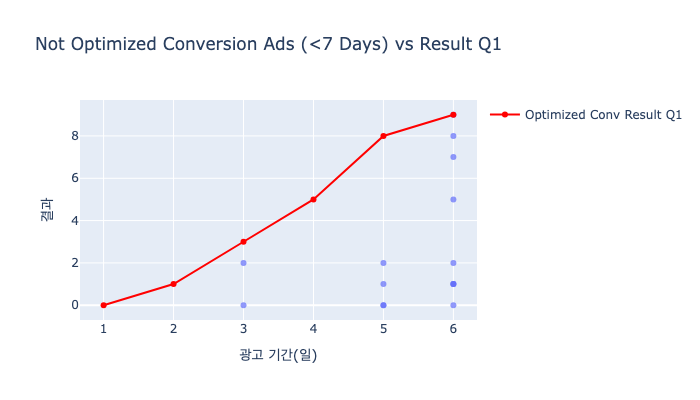

In [10]:
fig = px.scatter(
    not_opt_conv,
    x="ad_days",
    y="results",
    hover_data=["광고세트_이름", "roas_calc"],
    title="Not Optimized Conversion Ads (<7 Days) vs Result Q1",
    height=400,
    opacity=0.7
)

fig.add_scatter(
    x=conv_q1_by_day["ad_days"],
    y=conv_q1_by_day["result_q1"],
    mode="lines+markers",
    name="Optimized Conv Result Q1",
    line=dict(color="red")
)

fig.update_xaxes(tickmode="array", tickvals=[1,2,3,4,5,6], title="광고 기간(일)")
fig.update_yaxes(title="결과")
fig.show(renderer='png')

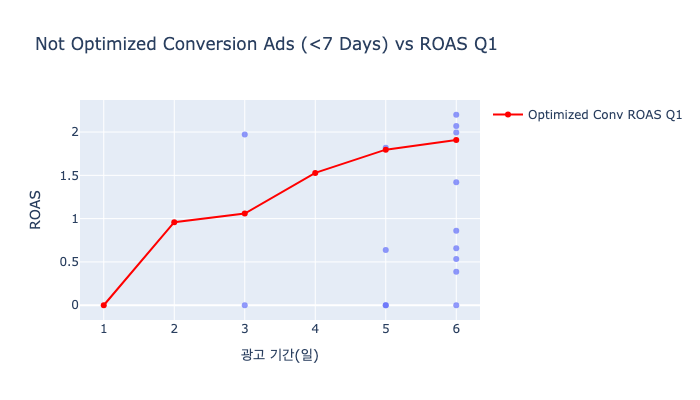

In [11]:
fig = px.scatter(
    not_opt_conv,
    x="ad_days",
    y="roas_calc",
    hover_data=["광고세트_이름", "results"],
    title="Not Optimized Conversion Ads (<7 Days) vs ROAS Q1",
    height=400,
    opacity=0.7
)

fig.add_scatter(
    x=conv_q1_by_day["ad_days"],
    y=conv_q1_by_day["roas_q1"],
    mode="lines+markers",
    name="Optimized Conv ROAS Q1",
    line=dict(color="red")
)

fig.update_xaxes(tickmode="array", tickvals=[1,2,3,4,5,6], title="광고 기간(일)")
fig.update_yaxes(title="ROAS")
fig.show(renderer='png')

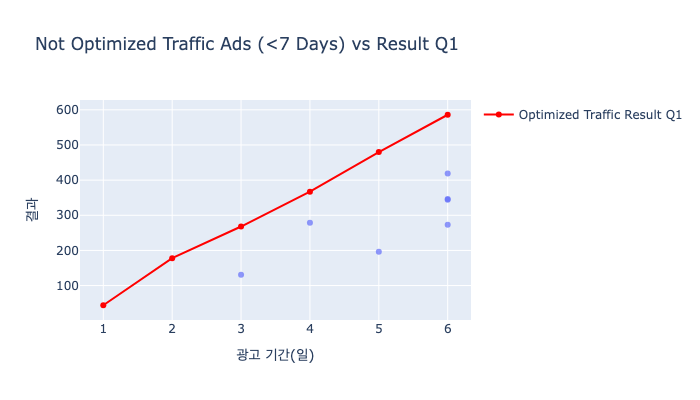

In [12]:
fig = px.scatter(
    not_opt_traffic,
    x="ad_days",
    y="results",
    hover_data=["광고세트_이름", "ctr_link_calc"],
    title="Not Optimized Traffic Ads (<7 Days) vs Result Q1",
    height=400,
    opacity=0.7
)

fig.add_scatter(
    x=traffic_q1_by_day["ad_days"],
    y=traffic_q1_by_day["result_q1"],
    mode="lines+markers",
    name="Optimized Traffic Result Q1",
    line=dict(color="red")
)

fig.update_xaxes(tickmode="array", tickvals=[1,2,3,4,5,6], title="광고 기간(일)")
fig.update_yaxes(title="결과")
fig.show(renderer='png')

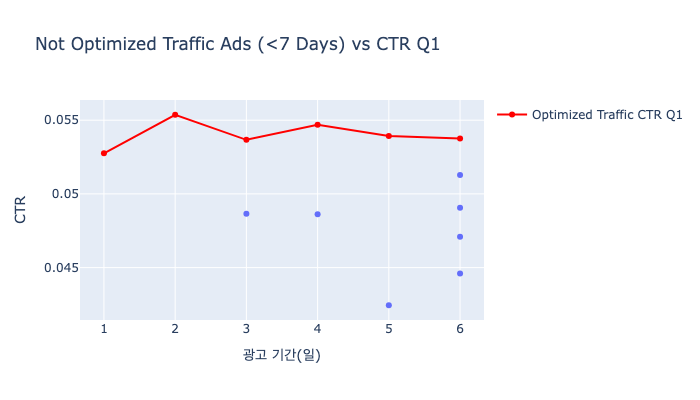

In [13]:
fig = px.scatter(
    not_opt_traffic,
    x="ad_days",
    y="ctr_link_calc",
    hover_data=["광고세트_이름", "results"],
    title="Not Optimized Traffic Ads (<7 Days) vs CTR Q1",
    height=400
)

fig.add_scatter(
    x=traffic_q1_by_day["ad_days"],
    y=traffic_q1_by_day["ctr_q1"],
    mode="lines+markers",
    name="Optimized Traffic CTR Q1",
    line=dict(color="red")
)

fig.update_xaxes(tickmode="array", tickvals=[1,2,3,4,5,6], title="광고 기간(일)")
fig.update_yaxes(title="CTR")
fig.show(renderer='png')

→ 초기 3~6일 구매 5~8건 / ROAS 1.5+ 달성 시 **최소 7일 유지 권장**

---
### 1-5. 비효율 광고 식별 — 최적화된 광고 중에서도 낭비되는 광고가 있는가?

학습 완료(최적화) 광고의 **광고비 × 성과 중앙값** 기준으로 사분면을 나누어 비효율 광고를 식별한다.
- **4사분면** (광고비↑ 성과↓): 소재 교체 또는 예산 축소 대상

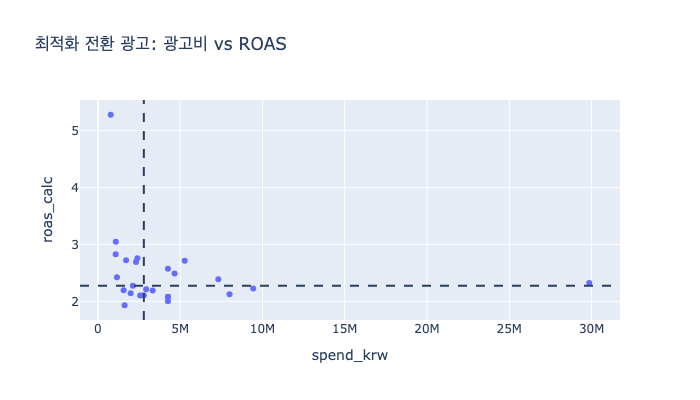

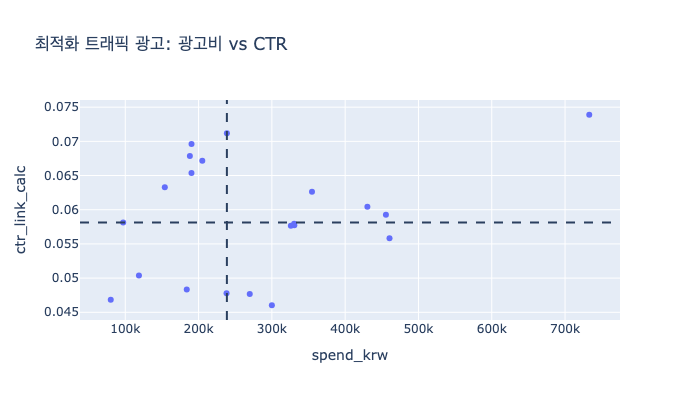

[구매] 4사분면 비효율: 8개 / 전체 최적화: 25개
[트래픽] 4사분면 비효율: 6개 / 전체 최적화: 21개


In [14]:
# 최적화 광고 사분면 분석

opt_conv = ad_summary_all[ad_summary_all["group"] == "optimized_conversion"].copy()
opt_trf = ad_summary_all[ad_summary_all["group"] == "optimized_traffic"].copy()

conv_spend_med = opt_conv["spend_krw"].median()
conv_roas_med = opt_conv["roas_calc"].median()

trf_spend_med = opt_trf["spend_krw"].median()
trf_ctr_med = opt_trf["ctr_link_calc"].median()

# 비효율 광고 식별
ineff_conv = opt_conv[(opt_conv["spend_krw"] >= conv_spend_med) & (opt_conv["roas_calc"] < conv_roas_med)]
ineff_trf = opt_trf[(opt_trf["spend_krw"] >= trf_spend_med) & (opt_trf["ctr_link_calc"] < trf_ctr_med)]

# 전환 광고 사분면
fig = px.scatter(
    opt_conv,
    x="spend_krw",
    y="roas_calc",
    hover_data=["광고세트_이름", "purchases", "purchase_value"],
    title="최적화 전환 광고: 광고비 vs ROAS",
    height=400
)
fig.add_vline(x=conv_spend_med, line_dash="dash")
fig.add_hline(y=conv_roas_med, line_dash="dash")
fig.show(renderer='png')

# 트래픽 광고 사분면
fig = px.scatter(
    opt_trf,
    x="spend_krw",
    y="ctr_link_calc",
    hover_data=["광고세트_이름", "link_clicks", "landing_page_views"],
    title="최적화 트래픽 광고: 광고비 vs CTR",
    height=400
)
fig.add_vline(x=trf_spend_med, line_dash="dash")
fig.add_hline(y=trf_ctr_med, line_dash="dash")
fig.show(renderer='png')

print(f"[구매] 4사분면 비효율: {len(ineff_conv)}개 / 전체 최적화: {len(opt_conv)}개")
print(f"[트래픽] 4사분면 비효율: {len(ineff_trf)}개 / 전체 최적화: {len(opt_trf)}개")

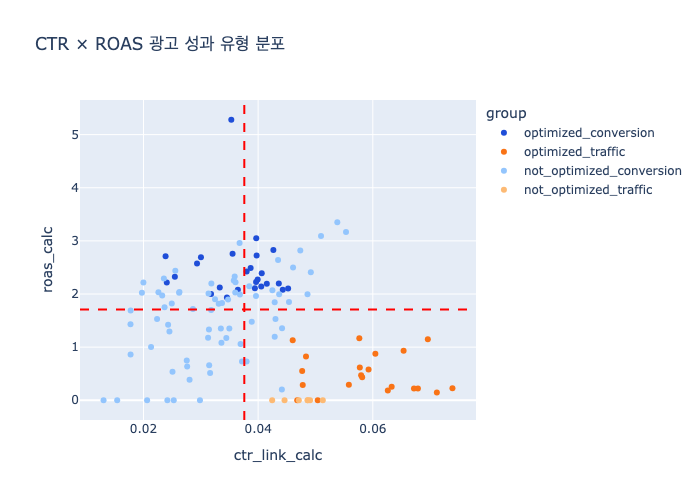

In [15]:
ctr_med = ad_summary_all["ctr_link_calc"].median()
roas_med = ad_summary_all["roas_calc"].median()

fig = px.scatter(
    ad_summary_all,
    x="ctr_link_calc",
    y="roas_calc",
    color="group",
    color_discrete_map=color_map,
    height=500,
    hover_data=["광고세트_이름", "성과_목표", "optimization_status", "spend_krw", "purchases"],
    title="CTR × ROAS 광고 성과 유형 분포"
)

fig.add_vline(x=ctr_med, line_dash="dash", line_color="red")
fig.add_hline(y=roas_med, line_dash="dash", line_color="red")
fig.show(renderer='png')

---
## PART 2 — 광고 콘텐츠 분석 (Content)

> "무엇이 성과를 만드는가?"

광고 본문 텍스트를 키워드 기반으로 태깅하고 메시지 유형별 성과를 비교한다.

In [16]:
import re

ad_level = df.groupby("광고 ID", as_index=False).agg({
    "광고 이름":"first", "캠페인 이름":"first", "광고 세트 이름":"first",
    "성과 목표":"first", "headline":"first", "설명":"first",
    "본문(광고 설정)":"first", "product_name":"first",
    "노출":"sum", "링크 클릭":"sum", "구매":"sum",
    "구매 전환값":"sum", "지출 금액 (KRW)":"sum", "랜딩 페이지 조회":"sum"
})
ad_level["CTR"] = ad_level["링크 클릭"] / ad_level["노출"]
ad_level["CVR"] = np.where(ad_level["링크 클릭"]>0, ad_level["구매"]/ad_level["링크 클릭"], 0)
ad_level["ROAS"] = np.where(ad_level["지출 금액 (KRW)"]>0, ad_level["구매 전환값"]/ad_level["지출 금액 (KRW)"], 0)

purchase_ads = ad_level[ad_level["구매"] > 0].copy()
for col in ["headline","설명","본문(광고 설정)"]:
    purchase_ads[col] = purchase_ads[col].fillna("").astype(str)
purchase_ads["message_text"] = (
    purchase_ads["headline"].str.strip() + " " +
    purchase_ads["설명"].str.strip() + " " +
    purchase_ads["본문(광고 설정)"].str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()
purchase_ads = purchase_ads[~purchase_ads["message_text"].str.contains("{{", na=False)].copy()

print(f"구매 발생 광고 (DPA 제외): {len(purchase_ads)}개")

구매 발생 광고 (DPA 제외): 298개


### 2-1. 메시지 유형 분류 및 성과 비교

In [17]:
event_kw = ["할인","세일","특가","혜택","쿠폰","증정","이벤트","프로모션","1+1","무료","한정","단독","사은품","특별가"]
product_kw = ["디자인","소재","원석","실버","골드","14k","18k","도금","퀄리티","디테일","사이즈","착용","아이템","컬러","고급스러운","스타일","룩"]
meaning_kw = ["선물","마음","의미","행운","소원","응원","위로","사랑","인연","행복","성공","보호","부모","가족","추억","소중한","특별한","함께","전하세요","당신에게","나를 위한","진심","감성","기념"]
strong_pairs = [["선물","행운"],["선물","마음"],["행운","가족"],["응원","마음"],["사랑","선물"],["인연","행운"]]

def auto_tag(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    e_cnt = sum(kw.lower() in text for kw in event_kw)
    p_cnt = sum(kw.lower() in text for kw in product_kw)
    m_cnt = sum(kw.lower() in text for kw in meaning_kw)
    for pair in strong_pairs:
        if all(p.lower() in text for p in pair): return "의미형"
    if m_cnt >= 2: return "의미형"
    if e_cnt >= 1: return "이벤트형"
    if p_cnt >= 1: return "제품 강조형"
    if m_cnt >= 1: return "의미형"
    return "미분류"

purchase_ads["message_type"] = purchase_ads["message_text"].apply(auto_tag)

msg_perf = purchase_ads.groupby("message_type").agg(
    광고수=("광고 ID","nunique"), 노출합=("노출","sum"), 클릭합=("링크 클릭","sum"),
    구매합=("구매","sum"), 매출합=("구매 전환값","sum"), 광고비합=("지출 금액 (KRW)","sum")
).reset_index()
msg_perf["CTR"] = msg_perf["클릭합"]/msg_perf["노출합"]
msg_perf["CVR"] = msg_perf["구매합"]/msg_perf["클릭합"]
msg_perf["ROAS"] = msg_perf["매출합"]/msg_perf["광고비합"]

msg_disp = msg_perf[msg_perf["message_type"]!="미분류"]
for _, r in msg_disp.iterrows():
    print(f"  {r['message_type']}: {int(r['광고수'])}개 | CTR {r['CTR']:.4f} | CVR {r['CVR']:.3f} | ROAS {r['ROAS']:.2f}")

  의미형: 212개 | CTR 0.0337 | CVR 0.023 | ROAS 2.31
  이벤트형: 42개 | CTR 0.0375 | CVR 0.021 | ROAS 2.15
  제품 강조형: 44개 | CTR 0.0401 | CVR 0.026 | ROAS 2.50


### 2-2. 의미형 메시지 심층 분석 (관계 vs 감정)

- 나(SELF)보다 **타인(관계) 지향** 메시지가 성과 우수
- **행복(HAPPINESS)** 메시지가 ROAS 최고, 행운(LUCK)은 상대적 저효율

In [18]:
meaning_ads = purchase_ads[purchase_ads["message_type"]=="의미형"].copy()

relation_kw = {"COUPLE":["커플","연인","우리"],"GIFT":["선물","전하세요","드리세요"],
               "FAMILY":["부모","가족","엄마","아빠","자식"],"SELF":["나를 위한","나다운","나만의"]}
emotion_kw = {"HAPPINESS":["행복","기쁨","미소"],"LUCK":["행운","소원","운","부적"],
              "LOVE":["사랑","인연","마음"],"PROTECTION":["보호","지킴","수호"],"SUCCESS":["성공","합격","응원"]}

def tag_sub(text, kw_dict):
    text = str(text).lower()
    return [label for label, kws in kw_dict.items() if any(kw in text for kw in kws)] or ["OTHER"]

meaning_ads["emotion_tags"] = meaning_ads["message_text"].apply(lambda x: tag_sub(x, emotion_kw))

# LUCK vs HAPPINESS
luck_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "LUCK" in x)]
happy_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "HAPPINESS" in x)]

luck_roas = luck_ads["ROAS"].mean() if len(luck_ads)>0 else 0
happy_roas = happy_ads["ROAS"].mean() if len(happy_ads)>0 else 0
print(f"LUCK: {len(luck_ads)}개 (ROAS {luck_roas:.2f}) | HAPPINESS: {len(happy_ads)}개 (ROAS {happy_roas:.2f})")

LUCK: 154개 (ROAS 3.82) | HAPPINESS: 16개 (ROAS 6.40)


### 2-3. ROAS 시뮬레이션 (LUCK → HAPPINESS 전환)

In [19]:
n_luck, n_happy = len(luck_ads), len(happy_ads)
n_total = n_luck + n_happy

if n_total > 0:
    scenarios = [("AS-IS",0),("10% 전환",0.10),("30% 전환",0.30),("50% 전환",0.50)]
    sim_results = []
    for name, shift in scenarios:
        shifted = int(n_luck * shift)
        sim_roas = (luck_roas*(n_luck-shifted) + happy_roas*(n_happy+shifted)) / n_total
        sim_results.append((name, sim_roas))

    baseline = sim_results[0][1]
    print(f"{'시나리오':<15} {'예상 ROAS':>10} {'개선율':>10}")
    print("-"*40)
    for name, roas in sim_results:
        imp = (roas/baseline-1)*100
        print(f"{name:<15} {roas:>9.2f} {'+' if imp>0 else ''}{imp:>8.1f}%")

시나리오               예상 ROAS        개선율
----------------------------------------
AS-IS                4.06      0.0%
10% 전환               4.29 +     5.6%
30% 전환               4.76 +    17.2%
50% 전환               5.23 +    28.8%


### 2-4. 소재 유형별 ROAS 분포

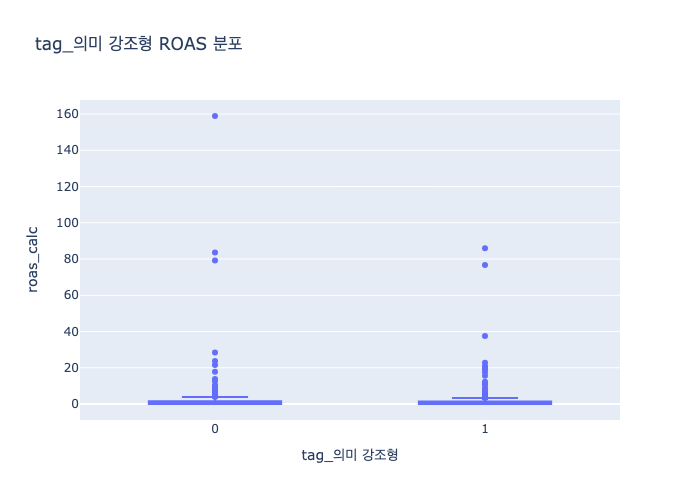

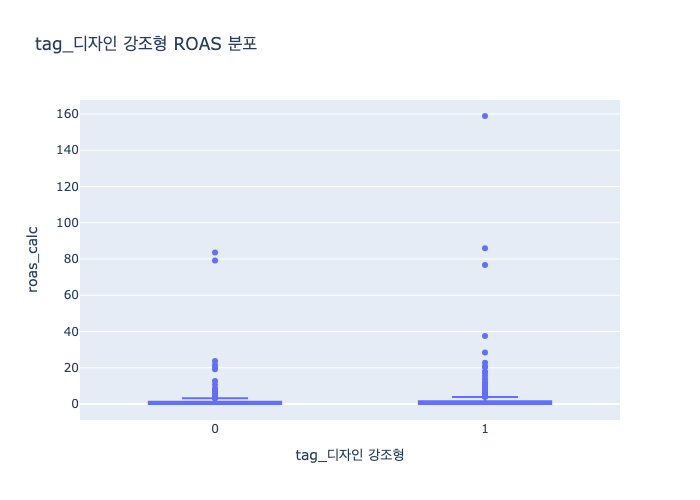

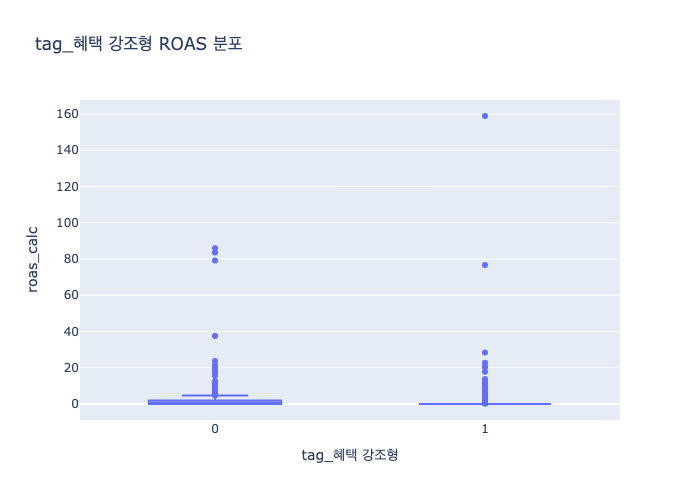

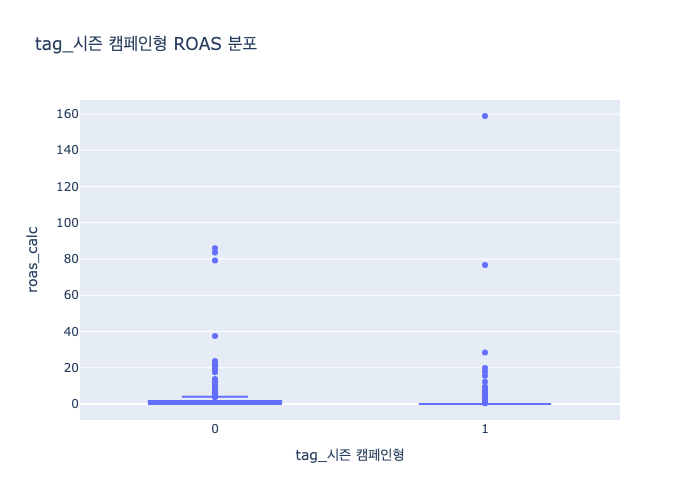

In [20]:
try:
    tag = pd.read_csv('ads_tagged.csv', encoding='utf-8-sig')
    # 마스킹
    tag["광고세트_이름"] = "adset_" + tag.reset_index().index.astype(str)

    tag_cols = ["tag_의미 강조형","tag_디자인 강조형","tag_혜택 강조형","tag_시즌 캠페인형"]

    for col in tag_cols:
        if col in tag.columns:
            fig = px.box(tag, x=col, y="roas_calc", title=f"{col} ROAS 분포")
            fig.show(renderer='png')
except FileNotFoundError:
    print("ads_tagged.csv 없음")

---
## PART 3 — 결론 및 실행 로드맵

### 광고 성과를 결정하는 3가지 요소

| 요소 | 핵심 발견 | 실행 방향 |
|------|----------|----------|
| **운영 구조** | 구매 광고 예산의 일부가 미최적화 상태에서 소진 | 최적화 전/후 운영 기준 적용 |
| **콘텐츠 메시지** | 행복+관계 조합이 ROAS 최고 효율 | 성과 중심 메시지 비중 확대 |
| **타겟·맥락** | 핵심 타겟 여성, 제품별 최적 소재 상이 | 맥락에 따른 소재 역할 분리 |

### 3단계 실행 로드맵

| 단계 | 시기 | 실행 항목 |
|------|------|----------|
| **1단계** | 즉시 | 조기 종료 방지 기준 + 비효율 광고 관리 기준 적용 |
| **2단계** | 1개월 내 | 비효율 예산 재배분 + HAPPINESS A/B 테스트 + 제품 강조형 확대 |
| **3단계** | 3개월 내 | 성과 광고 스케일업 + 운영 기준 재설정 + 주간 점검 프로세스 |

> **"조기 종료 방지 → 비효율 관리 → 성과 메시지 확대"의 선순환 구조를 만든다**